
# Coordinate Search vs. Derivative-Free Conjugate Directions on the Branin–Hoo Function

This notebook compares two derivative-free optimization methods on the **Branin–Hoo** test function:

1. **Coordinate search**
2. **Derivative-free conjugate directions** (in the Nocedal–Wright spirit)

The notebook shows:
- the optimization histories,
- the objective-value histories,
- the accepted step-size histories,
- and the trajectories on the Branin–Hoo contour plot.

Both methods start from the **same initial point**.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

try:
    rcParams["text.usetex"] = True
except Exception:
    rcParams["text.usetex"] = False

rcParams["font.size"] = 12
rcParams["axes.labelsize"] = 12
rcParams["axes.titlesize"] = 13

np.set_printoptions(precision=6, suppress=True)



## The Branin–Hoo function

We use the standard Branin–Hoo test function
\[
f(x_1,x_2)=
a\left(x_2-bx_1^2+cx_1-r\right)^2+s(1-t)\cos(x_1)+s,
\]
with
\[
a=1,\qquad
b=\frac{5.1}{4\pi^2},\qquad
c=\frac{5}{\pi},\qquad
r=6,\qquad
s=10,\qquad
t=\frac{1}{8\pi}.
\]

The box domain is
\[
x_1\in[-5,10], \qquad x_2\in[0,15].
\]


In [2]:

def branin(x):
    x = np.asarray(x, dtype=float)
    x1, x2 = x[..., 0], x[..., 1]
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

bounds = np.array([[-5.0, 10.0],
                   [ 0.0, 15.0]])

def project_to_bounds(x, bounds=bounds):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], bounds[0, 0], bounds[0, 1])
    x[1] = np.clip(x[1], bounds[1, 0], bounds[1, 1])
    return x


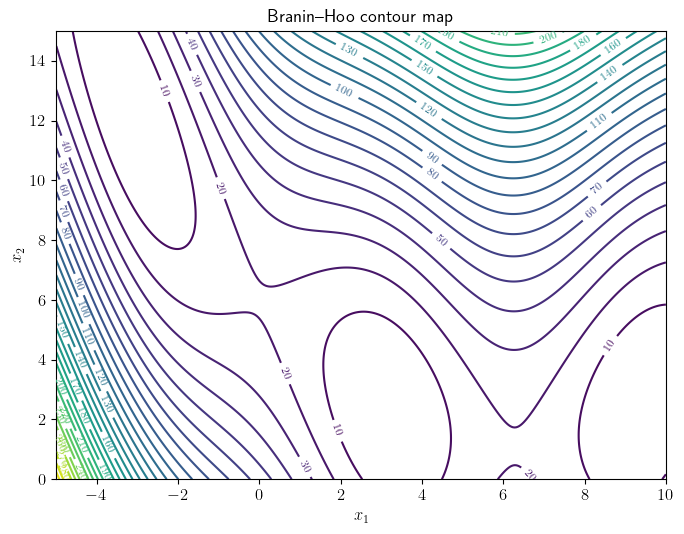

In [3]:

x1 = np.linspace(bounds[0, 0], bounds[0, 1], 400)
x2 = np.linspace(bounds[1, 0], bounds[1, 1], 400)
X1, X2 = np.meshgrid(x1, x2)
F = branin(np.stack([X1, X2], axis=-1))

plt.figure(figsize=(7, 5.5))
cs = plt.contour(X1, X2, F, levels=30)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Branin--Hoo contour map")
plt.tight_layout()
plt.show()



## Method 1: Coordinate search

Coordinate search polls the coordinate directions
\[
\{\pm e_1,\pm e_2\}
\]
with a current step size \(\Delta_k\). If a successful move is found, the iterate is updated. If no improving point is found, the step size is reduced.


In [4]:

def coordinate_search(
    f,
    x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=100,
    bounds=bounds,
):
    directions = [
        np.array([1.0, 0.0]),
        np.array([-1.0, 0.0]),
        np.array([0.0, 1.0]),
        np.array([0.0, -1.0]),
    ]

    x = project_to_bounds(x0, bounds)
    fx = float(f(x))
    delta = float(delta0)

    history = [{
        "iter": 0,
        "x": x.copy(),
        "f": fx,
        "delta": delta,
        "success": None,
        "accepted_direction": None,
        "step_norm": 0.0,
        "trials": []
    }]

    k = 0
    while delta > delta_min and k < max_iters:
        improved = False
        accepted_direction = None
        step_norm = 0.0
        trials = []

        x_old = x.copy()

        for d in directions:
            x_trial = project_to_bounds(x + delta * d, bounds)
            f_trial = float(f(x_trial))

            trials.append({
                "direction": d.copy(),
                "x_trial": x_trial.copy(),
                "f_trial": f_trial
            })

            if f_trial < fx:
                x = x_trial
                fx = f_trial
                improved = True
                accepted_direction = d.copy()
                step_norm = float(np.linalg.norm(x - x_old))
                break

        if not improved:
            delta *= shrink

        k += 1
        history.append({
            "iter": k,
            "x": x.copy(),
            "f": fx,
            "delta": delta,
            "success": improved,
            "accepted_direction": accepted_direction,
            "step_norm": step_norm,
            "trials": trials
        })

    return history



## Method 2: Derivative-free conjugate directions

This implementation follows the classical derivative-free line-search viewpoint associated with conjugate directions and Powell-style direction updates:

- begin with coordinate directions,
- perform one-dimensional minimizations along each direction,
- after a full cycle, form a new direction from the net displacement over the cycle,
- replace one old direction by this new direction.

For a quadratic objective with exact line searches, conjugate directions have a finite-step interpretation. On Branin–Hoo, this should be viewed as a structured derivative-free analogue.


In [5]:

def line_search_grid(f, x, d, alpha_max=4.0, ngrid=401, bounds=bounds):
    """
    Derivative-free 1D search over alpha in [-alpha_max, alpha_max].
    The direction is normalized so alpha corresponds to distance moved.
    """
    d = np.asarray(d, dtype=float)
    norm_d = np.linalg.norm(d)

    if norm_d == 0.0:
        fx = float(f(x))
        return {
            "alpha_star": 0.0,
            "x_new": x.copy(),
            "f_new": fx,
            "alphas": np.array([0.0]),
            "phi_vals": np.array([fx]),
            "direction_unit": np.zeros_like(d),
        }

    d_unit = d / norm_d
    alphas = np.linspace(-alpha_max, alpha_max, ngrid)

    phi_vals = []
    xs = []
    for alpha in alphas:
        x_trial = project_to_bounds(x + alpha * d_unit, bounds)
        xs.append(x_trial)
        phi_vals.append(float(f(x_trial)))

    phi_vals = np.array(phi_vals, dtype=float)
    xs = np.array(xs, dtype=float)
    idx = int(np.argmin(phi_vals))

    return {
        "alpha_star": float(alphas[idx]),
        "x_new": xs[idx].copy(),
        "f_new": float(phi_vals[idx]),
        "alphas": alphas,
        "phi_vals": phi_vals,
        "direction_unit": d_unit.copy(),
    }


In [6]:

def derivative_free_conjugate_directions(
    f,
    x0,
    directions0=None,
    alpha_max=4.0,
    ngrid=401,
    max_cycles=20,
    tol_disp=1e-4,
    tol_f=1e-8,
    bounds=bounds,
):
    x = project_to_bounds(x0, bounds)
    fx = float(f(x))

    n = len(x)
    if directions0 is None:
        directions = [np.eye(n)[i].copy() for i in range(n)]
    else:
        directions = [np.asarray(d, dtype=float).copy() for d in directions0]

    history = [{
        "stage": "start",
        "cycle": 0,
        "substep": 0,
        "x": x.copy(),
        "f": fx,
        "direction": None,
        "alpha": 0.0,
        "step_norm": 0.0,
        "directions_snapshot": [d.copy() for d in directions],
        "line_search": None,
    }]

    for cycle in range(1, max_cycles + 1):
        x_cycle_start = x.copy()
        f_cycle_start = fx
        old_directions = [d.copy() for d in directions]

        for j, d in enumerate(old_directions, start=1):
            ls = line_search_grid(
                f=f,
                x=x,
                d=d,
                alpha_max=alpha_max,
                ngrid=ngrid,
                bounds=bounds,
            )

            x_new = ls["x_new"]
            f_new = ls["f_new"]
            alpha_star = ls["alpha_star"]
            step_norm = float(np.linalg.norm(x_new - x))

            x = x_new
            fx = f_new

            history.append({
                "stage": "line_search",
                "cycle": cycle,
                "substep": j,
                "x": x.copy(),
                "f": fx,
                "direction": d.copy(),
                "alpha": alpha_star,
                "step_norm": step_norm,
                "directions_snapshot": [dd.copy() for dd in directions],
                "line_search": ls,
            })

        displacement = x - x_cycle_start
        disp_norm = float(np.linalg.norm(displacement))

        history.append({
            "stage": "cycle_summary",
            "cycle": cycle,
            "substep": 0,
            "x": x.copy(),
            "f": fx,
            "direction": displacement.copy(),
            "alpha": None,
            "step_norm": disp_norm,
            "directions_snapshot": [d.copy() for d in directions],
            "line_search": None,
        })

        if disp_norm < tol_disp or abs(f_cycle_start - fx) < tol_f:
            break

        if disp_norm > 0.0:
            directions = directions[1:] + [displacement.copy()]
        else:
            break

    return history



## Run both methods from the same initial point


In [15]:

x0 = np.array([6.0, 12.0])

cs_hist = coordinate_search(
    branin,
    x0=x0,
    delta0=1.0,
    delta_min=1e-3,
    shrink=0.5,
    max_iters=60,
    bounds=bounds,
)

cd_hist = derivative_free_conjugate_directions(
    branin,
    x0=x0,
    alpha_max=4.0,
    ngrid=401,
    max_cycles=20,
    tol_disp=1e-4,
    tol_f=1e-8,
    bounds=bounds,
)

print("Initial point x0 =", x0)
print("Initial objective =", branin(x0))
print()
print("Coordinate search final point:", cs_hist[-1]["x"])
print("Coordinate search final objective:", cs_hist[-1]["f"])
print("Coordinate search iterations:", len(cs_hist) - 1)
print()
print("Conjugate directions final point:", cd_hist[-1]["x"])
print("Conjugate directions final objective:", cd_hist[-1]["f"])
print("Conjugate directions completed cycles:", max(r["cycle"] for r in cd_hist))


Initial point x0 = [ 6. 12.]
Initial objective = 138.00032784720685

Coordinate search final point: [9.425781 2.476562]
Coordinate search final objective: 0.39789270318346226
Coordinate search iterations: 36

Conjugate directions final point: [2.720823 2.349591]
Conjugate directions final objective: 1.3118441546518778
Conjugate directions completed cycles: 4



## Inspect the optimization histories

The coordinate-search printout records one accepted poll step per iteration.  
The conjugate-directions printout records the accepted one-dimensional line-search steps.


In [16]:

def print_coordinate_history(history, num_iters=8):
    print("Coordinate search")
    print("-" * 60)
    for rec in history[:num_iters + 1]:
        print(
            f"iter={rec['iter']:2d}, "
            f"x={rec['x']}, "
            f"f={rec['f']:.6f}, "
            f"delta={rec['delta']:.6f}, "
            f"step_norm={rec['step_norm']:.6f}, "
            f"success={rec['success']}"
        )

def print_conjugate_history(history, num_steps=12):
    print("Conjugate directions")
    print("-" * 60)
    count = 0
    for rec in history:
        if rec["stage"] == "start":
            print(f"start: x={rec['x']}, f={rec['f']:.6f}")
        elif rec["stage"] == "line_search":
            count += 1
            print(
                f"step={count:2d}, cycle={rec['cycle']:2d}, substep={rec['substep']}, "
                f"x={rec['x']}, f={rec['f']:.6f}, "
                f"alpha={rec['alpha']:.6f}, "
                f"step_norm={rec['step_norm']:.6f}"
            )
            if count >= num_steps:
                break

print_coordinate_history(cs_hist, num_iters=8)
print()
print_conjugate_history(cd_hist, num_steps=12)


Coordinate search
------------------------------------------------------------
iter= 0, x=[ 6. 12.], f=138.000328, delta=1.000000, step_norm=0.000000, success=None
iter= 1, x=[ 7. 12.], f=134.112561, delta=1.000000, step_norm=1.000000, success=True
iter= 2, x=[ 8. 12.], f=118.110470, delta=1.000000, step_norm=1.000000, success=True
iter= 3, x=[ 9. 12.], f=98.470817, delta=1.000000, step_norm=1.000000, success=True
iter= 4, x=[10. 12.], f=82.889931, delta=1.000000, step_norm=1.000000, success=True
iter= 5, x=[10. 11.], f=65.895844, delta=1.000000, step_norm=1.000000, success=True
iter= 6, x=[10. 10.], f=50.901757, delta=1.000000, step_norm=1.000000, success=True
iter= 7, x=[10.  9.], f=37.907670, delta=1.000000, step_norm=1.000000, success=True
iter= 8, x=[10.  8.], f=26.913583, delta=1.000000, step_norm=1.000000, success=True

Conjugate directions
------------------------------------------------------------
start: x=[ 6. 12.], f=138.000328
step= 1, cycle= 1, substep=1, x=[ 2. 12.], f=8


## Extract paths and histories for comparison


In [17]:

cs_path = np.array([rec["x"] for rec in cs_hist], dtype=float)
cs_f = np.array([rec["f"] for rec in cs_hist], dtype=float)
cs_step = np.array([rec["step_norm"] for rec in cs_hist], dtype=float)
cs_delta = np.array([rec["delta"] for rec in cs_hist], dtype=float)

cd_line_recs = [rec for rec in cd_hist if rec["stage"] == "line_search"]
cd_path = np.array([cd_hist[0]["x"]] + [rec["x"] for rec in cd_line_recs], dtype=float)
cd_f = np.array([cd_hist[0]["f"]] + [rec["f"] for rec in cd_line_recs], dtype=float)
cd_step = np.array([0.0] + [rec["step_norm"] for rec in cd_line_recs], dtype=float)
cd_alpha = np.array([0.0] + [rec["alpha"] for rec in cd_line_recs], dtype=float)

print("Coordinate search path shape:", cs_path.shape)
print("Conjugate directions path shape:", cd_path.shape)


Coordinate search path shape: (37, 2)
Conjugate directions path shape: (9, 2)



## Trajectories on the Branin–Hoo contours


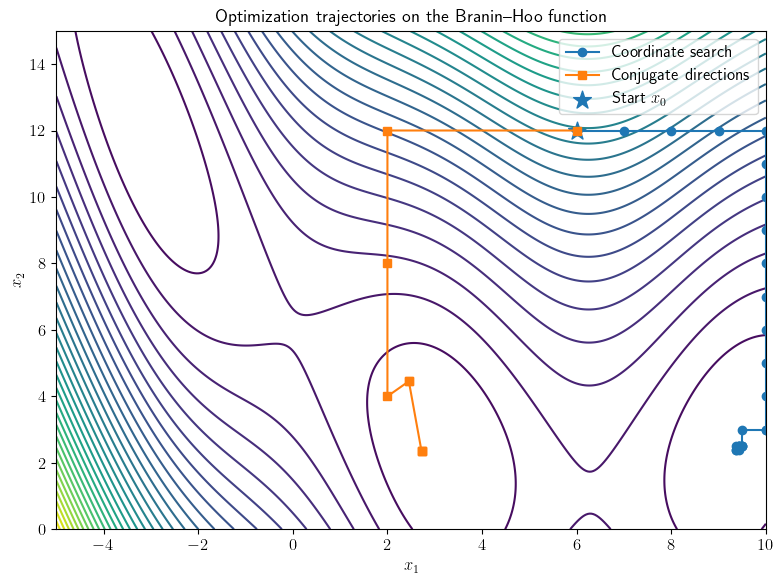

In [18]:

plt.figure(figsize=(8, 6))
plt.contour(X1, X2, F, levels=35)
plt.plot(cs_path[:, 0], cs_path[:, 1], marker="o", label="Coordinate search")
plt.plot(cd_path[:, 0], cd_path[:, 1], marker="s", label="Conjugate directions")
plt.scatter([x0[0]], [x0[1]], marker="*", s=180, label=r"Start $x_0$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Optimization trajectories on the Branin--Hoo function")
plt.legend()
plt.tight_layout()
plt.show()



## Objective-value histories


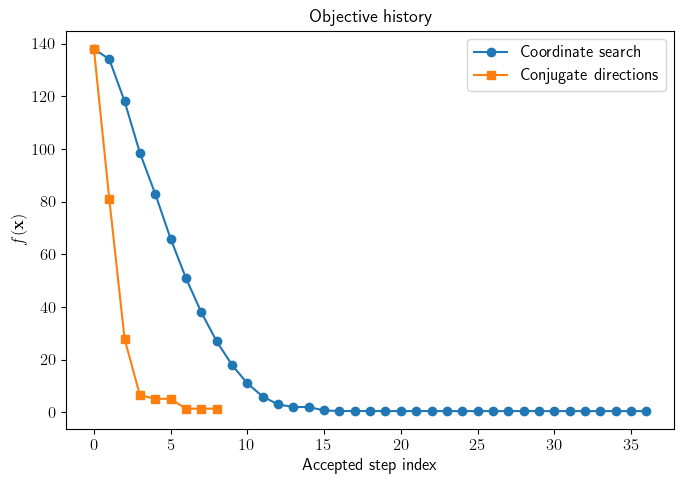

In [19]:

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_f)), cs_f, marker="o", label="Coordinate search")
plt.plot(np.arange(len(cd_f)), cd_f, marker="s", label="Conjugate directions")
plt.xlabel("Accepted step index")
plt.ylabel(r"$f(\mathbf{x})$")
plt.title(r"Objective history")
plt.legend()
plt.tight_layout()
plt.show()



## Accepted step-size histories

For coordinate search, the accepted step size is the norm of the accepted poll move.  
For conjugate directions, the accepted step size is the norm of the accepted line-search move.


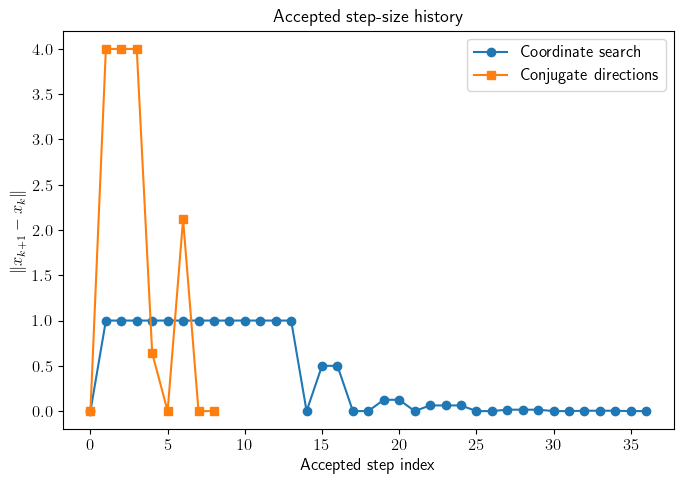

In [20]:

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_step)), cs_step, marker="o", label="Coordinate search")
plt.plot(np.arange(len(cd_step)), cd_step, marker="s", label="Conjugate directions")
plt.xlabel("Accepted step index")
plt.ylabel(r"$\|x_{k+1}-x_k\|$")
plt.title(r"Accepted step-size history")
plt.legend()
plt.tight_layout()
plt.show()



## Method-specific step parameters

Coordinate search has an explicit poll size \(\Delta_k\).  
Conjugate directions uses one-dimensional line searches, so its natural scalar parameter is the accepted line-search value \(\alpha^\star\).


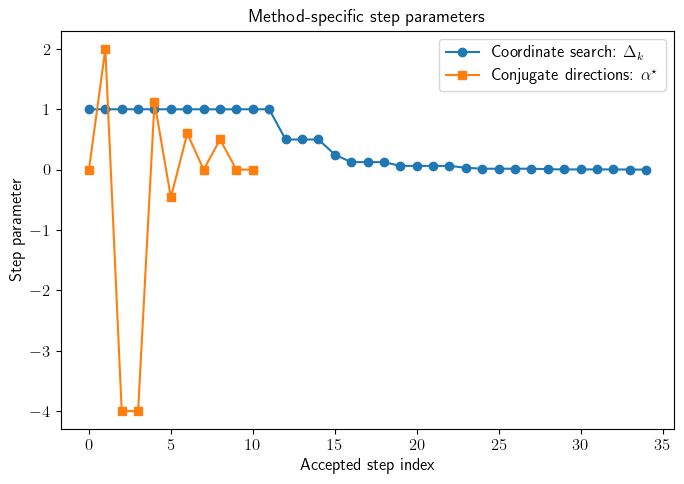

In [13]:

plt.figure(figsize=(7, 5))
plt.plot(np.arange(len(cs_delta)), cs_delta, marker="o", label=r"Coordinate search: $\Delta_k$")
plt.plot(np.arange(len(cd_alpha)), cd_alpha, marker="s", label=r"Conjugate directions: $\alpha^\star$")
plt.xlabel("Accepted step index")
plt.ylabel("Step parameter")
plt.title(r"Method-specific step parameters")
plt.legend()
plt.tight_layout()
plt.show()



## Quantitative summary


In [14]:

def summarize_coordinate(history):
    xs = np.array([rec["x"] for rec in history], dtype=float)
    fs = np.array([rec["f"] for rec in history], dtype=float)
    return {
        "method": "Coordinate search",
        "final_x": xs[-1],
        "final_f": fs[-1],
        "accepted_steps": len(history) - 1,
        "path_length": float(np.sum(np.linalg.norm(xs[1:] - xs[:-1], axis=1))),
        "successful_iters": int(np.sum(np.diff(fs) < 0.0)),
    }

def summarize_conjugate(history):
    line_recs = [rec for rec in history if rec["stage"] == "line_search"]
    xs = np.array([history[0]["x"]] + [rec["x"] for rec in line_recs], dtype=float)
    fs = np.array([history[0]["f"]] + [rec["f"] for rec in line_recs], dtype=float)
    return {
        "method": "Conjugate directions",
        "final_x": xs[-1],
        "final_f": fs[-1],
        "accepted_steps": len(xs) - 1,
        "path_length": float(np.sum(np.linalg.norm(xs[1:] - xs[:-1], axis=1))),
        "successful_iters": int(np.sum(np.diff(fs) < 0.0)),
    }

for summary in [summarize_coordinate(cs_hist), summarize_conjugate(cd_hist)]:
    print(summary["method"])
    print("  final_x         =", summary["final_x"])
    print("  final_f         =", summary["final_f"])
    print("  accepted_steps  =", summary["accepted_steps"])
    print("  path_length     =", summary["path_length"])
    print("  successful moves=", summary["successful_iters"])
    print()


Coordinate search
  final_x         = [9.425781 2.476562]
  final_f         = 0.39789270318346226
  accepted_steps  = 34
  path_length     = 12.49609375
  successful moves= 24

Conjugate directions
  final_x         = [9.425694 2.471827]
  final_f         = 0.3979069611143604
  accepted_steps  = 10
  path_length     = 12.561758453919905
  successful moves= 7




## Discussion

The two methods differ structurally:

- **Coordinate search** uses local polling along axis-aligned directions with an explicit poll size.
- **Derivative-free conjugate directions** uses line searches and updates directions from accumulated progress over a cycle.

On Branin–Hoo, coordinate search often makes smaller, more local moves. The conjugate-directions method can make larger coordinated displacements because each accepted step comes from a one-dimensional minimization along a chosen direction rather than from a single fixed poll step.

This notebook lets you compare those differences directly through:
- the trajectories,
- the objective histories,
- and the step-size histories.
